# 4.0 - Abertura da Fase 4: justificativa, objetivos, dados e roteiro

**Projeto NINO-BRASIL - Oceanografia Fisica UFPE - Thiago Vilar**
**Escopo estritamente Pacifico -> Brasil. Sem indices de outras bacias. Sem ML nesta fase.**

---

## 1. Justificativa

As Fases 1-3 fecharam o **diagnostico fisico do Pacifico equatorial**: como o sinal do Nino 3.4 nasce, cresce, atinge o pico e decai, e quais variaveis de recarga o antecipam. A pergunta da tese, porem, e sobre o **Brasil**: quando e onde o El Nino (e a La Nina) mudam a chuva. A Fase 4 e a ponte estatistica entre o oceano Pacifico e a precipitacao brasileira - a primeira secao de resultados diretamente ligada ao titulo do projeto.

O desenho segue tres exigencias metodologicas que sustentam um parecer auditavel:

- **Ciclo antes de correlacao.** O El Nino nao e um estado unico: tem 4 fases (I. Genese, II. Crescimento/acoplamento, III. Pico, IV. Decaimento). Misturar as fases num unico coeficiente esconde o mecanismo. Por isso separamos o ciclo primeiro (4A) e so entao medimos o que cada fase faz.
- **Pixel antes de regiao.** A teleconexao e espacialmente heterogenea. Agregar o Brasil em regioes administrativas antes de olhar o campo mascara onde o sinal realmente atua. A distribuicao e feita pixel-a-pixel (4C) e so depois os alvos emergem por clusterizacao (4D).
- **Evidencia antes de modelo.** Nenhuma figura sem saida numerica; toda significancia com graus de liberdade efetivos (N_eff de Bretherton) e FDR de Benjamini-Hochberg. O gate G1 (4D) decide o que e defensavel o suficiente para alimentar a modelagem das Fases 5-6.

## 2. Objetivos

1. Separar o ciclo ENSO local em 4 fases, de forma logica e estatisticamente coerente, **simetricamente para El Nino e La Nina**.
2. Descobrir, por estatistica pura, **quais variaveis do Pacifico mais determinam cada fase**.
3. Medir **quanto tempo (em semanas) o sinal demora para afetar a chuva** do Brasil, distribuido **pixel-a-pixel**, com detalhamento do Nordeste (NEB) e do Sul.
4. Identificar os **alvos regionais mais afetados** (clusters derivados do sinal) e o lag de atuacao de cada tipo de sinal, com teste de estabilidade temporal e uma tabela-gate de variaveis para as fases de modelagem.

## 3. Metodologia (visao geral)

| Principio | Como e aplicado |
|---|---|
| Eixo temporal | Semana canonica W-SUN (`week_ending_sunday`); CHIRPS diario somado por semana |
| Anomalia | Climatologia harmonica (2-3 harmonicos anuais) na base 1991-2020; nunca 52 medias cruas |
| Eventos e fases | ONI local (media movel 3 meses da SSTA Nino 3.4); criterio simetrico +-0,5 C por 5+ estacoes; sem rotulo ENSO externo |
| Significancia | N_eff de Bretherton em toda correlacao; FDR Benjamini-Hochberg (alfa=0,10) sobre o conjunto completo de testes |
| Distribuicao espacial | Pixel-a-pixel (CHIRPS 0,25 grau) antes de qualquer agregacao regional |
| Escopo | Estritamente Pacifico -> Brasil; nenhuma covariavel de outra bacia |

Este notebook (4.0) e **pre-flight**: apresenta o inventario dos dados disponiveis e a sanidade de cobertura. Ele nao produz resultado cientifico - os calculos vivem em 4A-4D.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase4_utils as u

# --- Inventario 1: conjunto de variaveis do Pacifico (matriz semanal da Fase 3) ---
w = u.load_pacific_weekly()
desc = {
 'nino34_ssta': ('SSTA Nino 3.4', 'C', 'anomalia de TSM; alvo termico do ENSO'),
 'd20_m': ('Profundidade da termoclina (D20)', 'm', 'recarga/subsuperficie'),
 'ohc_0_300': ('Conteudo de calor 0-300 m', 'J m-2', 'recarga/subsuperficie'),
 'ohc_0_700': ('Conteudo de calor 0-700 m', 'J m-2', 'recarga/subsuperficie'),
 'wwv': ('Volume de agua quente (WWV)', 'm3', 'recarga; memoria de longo lead'),
 'tilt_m': ('Inclinacao da termoclina', 'm', 'recarga/gradiente zonal'),
 'ssh_m': ('Altura da superficie do mar', 'm', 'recarga/subsuperficie'),
 'tau_x_anom_nino34_pa': ('Anomalia de estresse zonal do vento', 'Pa', 'acoplamento vento-superficie'),
}
inv = pd.DataFrame([{
    'variavel': c, 'descricao': desc[c][0], 'unidade': desc[c][1], 'papel_fisico': desc[c][2],
    'inicio': w[c].first_valid_index().date(), 'fim': w[c].last_valid_index().date(),
    'semanas_validas': int(w[c].notna().sum()), 'cobertura_%': round(100*w[c].notna().mean(),1),
} for c in w.columns])
u.save_table(inv, 'phase40_inventario_pacifico.csv', index=False)
print('CONJUNTO PACIFICO (forcantes) - matriz semanal', w.shape)
print(inv.to_string(index=False))

[tabela] data/processed/parquet/statistics/phase40_inventario_pacifico.csv
CONJUNTO PACIFICO (forcantes) - matriz semanal (2372, 8)
            variavel                           descricao unidade                          papel_fisico     inicio        fim  semanas_validas  cobertura_%
         nino34_ssta                       SSTA Nino 3.4       C anomalia de TSM; alvo termico do ENSO 1981-09-06 2026-06-14             2337         98.5
               d20_m    Profundidade da termoclina (D20)       m                 recarga/subsuperficie 1981-09-06 2026-06-14             2337         98.5
           ohc_0_300           Conteudo de calor 0-300 m   J m-2                 recarga/subsuperficie 1981-09-06 2026-06-14             2337         98.5
           ohc_0_700           Conteudo de calor 0-700 m   J m-2                 recarga/subsuperficie 1981-09-06 2026-06-14             2337         98.5
               ssh_m         Altura da superficie do mar       m                 recarga/subs

In [2]:
# --- Inventario 2: alvo (chuva CHIRPS) e serie de eventos/ONI ---
import xarray as xr
stores = sorted(u.RAIN_ZARR.glob('chirps_p25_*.zarr'))
anos = [int(s.name.split('_')[-1].replace('.zarr','')) for s in stores]
ds0 = xr.open_zarr(stores[len(stores)//2], consolidated=False)
da = ds0['precip'].sel(latitude=slice(u.BRAZIL_BOX['lat_min'], u.BRAZIL_BOX['lat_max']),
                       longitude=slice(u.BRAZIL_BOX['lon_min'], u.BRAZIL_BOX['lon_max']))
alvo = pd.DataFrame([
 {'fonte': 'CHIRPS precip diaria', 'papel': 'alvo (chuva Brasil)', 'unidade': 'mm/dia',
  'resolucao': '0.25 grau', 'cobertura': f'{min(anos)}-{max(anos)} ({len(anos)} anos)',
  'grade_recorte_brasil': f"{da.sizes.get('latitude','?')} lat x {da.sizes.get('longitude','?')} lon",
  'obs': 'somada para semana W-SUN; anomalia padronizada por pixel em 4C'},
], )
u.save_table(alvo, 'phase40_inventario_alvo.csv', index=False)
print('ALVO - chuva'); print(alvo.to_string(index=False))

oni = u.load_oni_monthly()
ev = u.enso_events(oni)
print(f"\nSerie ONI local: {oni.dropna().index.min().date()} a {oni.dropna().index.max().date()} ({oni.notna().sum()} meses)")
print(f"Eventos derivados (criterio local simetrico): {int((ev.tipo=='el_nino').sum())} El Nino + {int((ev.tipo=='la_nina').sum())} La Nina")
reg = pd.DataFrame([{'regiao': k, **v} for k, v in u.REGIOES.items()])
print('\nRecortes regionais de detalhamento (4C):'); print(reg.to_string(index=False))

[tabela] data/processed/parquet/statistics/phase40_inventario_alvo.csv
ALVO - chuva
               fonte               papel unidade resolucao           cobertura grade_recorte_brasil                                                            obs
CHIRPS precip diaria alvo (chuva Brasil)  mm/dia 0.25 grau 1981-2026 (46 anos)    168 lat x 172 lon somada para semana W-SUN; anomalia padronizada por pixel em 4C

Serie ONI local: 1981-10-01 a 2026-05-01 (536 meses)
Eventos derivados (criterio local simetrico): 12 El Nino + 11 La Nina

Recortes regionais de detalhamento (4C):
regiao  lat_min  lat_max  lon_min  lon_max
   NEB    -18.0     -1.0    -48.0    -34.5
   SUL    -34.0    -22.0    -58.0    -48.0


[figura] data/processed/figures/fase4/phase40_cobertura_dados.png


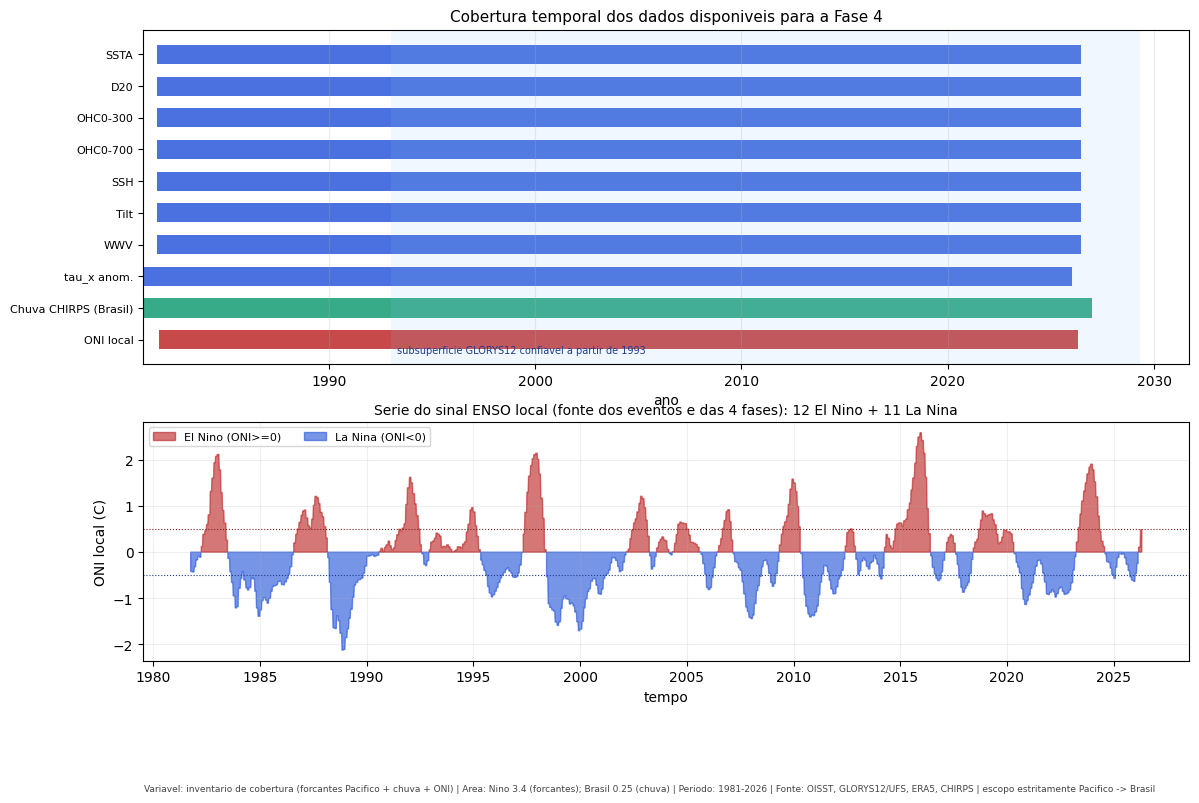

In [3]:
# --- Painel visual: cobertura temporal de todos os dados disponiveis para a Fase 4 ---
fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.2), gridspec_kw={'height_ratios':[1.4, 1]})
ax = axes[0]
linhas = list(w.columns) + ['chuva_chirps_brasil', 'oni_local']
spans = {c: (w[c].first_valid_index(), w[c].last_valid_index()) for c in w.columns}
spans['chuva_chirps_brasil'] = (pd.Timestamp(f'{min(anos)}-01-01'), pd.Timestamp(f'{max(anos)}-12-31'))
spans['oni_local'] = (oni.dropna().index.min(), oni.dropna().index.max())
cores = ['#1d4ed8']*len(w.columns) + ['#059669', '#b91c1c']
for i, c in enumerate(linhas):
    a, b = spans[c]
    ax.barh(i, (b-a).days/365.25, left=a.year + a.dayofyear/365.25, color=cores[i], alpha=.8, height=.6)
ax.set_yticks(range(len(linhas)))
ax.set_yticklabels([u.var_label(c) if c in w.columns else ('Chuva CHIRPS (Brasil)' if 'chirps' in c else 'ONI local') for c in linhas], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('ano'); ax.grid(axis='x', alpha=.25)
ax.set_title('Cobertura temporal dos dados disponiveis para a Fase 4', fontsize=11)
ax.axvspan(1993, ax.get_xlim()[1], color='#93c5fd', alpha=.12, lw=0)
ax.text(1993.3, len(linhas)-0.5, 'subsuperficie GLORYS12 confiavel a partir de 1993', fontsize=7, color='#1e3a8a', va='bottom')

ax2 = axes[1]
oni_w = oni.reindex(pd.date_range(oni.index.min(), oni.index.max(), freq='W-SUN'), method='ffill')
ax2.fill_between(oni_w.index, 0, oni_w.values, where=(oni_w.values>=0), color='#b91c1c', alpha=.6, label='El Nino (ONI>=0)')
ax2.fill_between(oni_w.index, 0, oni_w.values, where=(oni_w.values<0), color='#1d4ed8', alpha=.6, label='La Nina (ONI<0)')
ax2.axhline(0.5, color='#7f1d1d', ls=':', lw=.8); ax2.axhline(-0.5, color='#1e3a8a', ls=':', lw=.8)
ax2.set_ylabel('ONI local (C)'); ax2.set_xlabel('tempo'); ax2.legend(fontsize=8, ncol=2, loc='upper left')
ax2.set_title(f'Serie do sinal ENSO local (fonte dos eventos e das 4 fases): {int((ev.tipo=="el_nino").sum())} El Nino + {int((ev.tipo=="la_nina").sum())} La Nina', fontsize=10)
ax2.grid(alpha=.2)
u.stamp_caption(fig, variavel='inventario de cobertura (forcantes Pacifico + chuva + ONI)', area='Nino 3.4 (forcantes); Brasil 0.25 (chuva)', periodo=f'{min(anos)}-{max(anos)}', fonte='OISST, GLORYS12/UFS, ERA5, CHIRPS', extra='escopo estritamente Pacifico -> Brasil')
u.save_fig(fig, 'phase40_cobertura_dados.png')
plt.show()

## 4. Roteiro: que pergunta cada notebook responde

| NB | Pergunta central | Metodo-chave | Saida de decisao |
|---|---|---|---|
| **4A** | Como separar o ciclo ENSO em 4 fases (genese, crescimento, pico, decaimento), para El Nino e La Nina? Quanto dura cada fase? | Eventos ONI local simetricos; plateau de 90% define o pico; genese = 26 sem pre-onset | Rotulo semanal das fases (`phase4A_fases_semanais.csv`) que condiciona 4B-4D |
| **4B** | Quais variaveis do Pacifico mais **determinam** cada fase? | Estatistica pura: delta de Cliff (fase vs neutro) + Kruskal/epsilon2 (entre fases) + Spearman (genese -> intensidade do pico) | Ranking de determinantes por fase e por tipo de sinal |
| **4C** | Quanto tempo (semanas) o sinal do El Nino e da La Nina demora para afetar a chuva? Onde? | Correlacao defasada **pixel-a-pixel** (lags 0-78 sem), N_eff + FDR; Brasil inteiro -> recorte NEB -> recorte Sul | Atlas espacial + lag de resposta por regiao e tipo de sinal |
| **4D** | Quais os **alvos clusterizados** mais afetados e em que lag atua cada tipo de sinal? O sinal e estavel? | K-means dos perfis r(lag); estabilidade 1993-2009 vs 2010+; gate para ML | Alvos ranqueados + tabela-gate (`phase4D_gate_ml.csv`) para as Fases 5-6 |

**Fluxo de dependencia:** 4A (fases) -> 4B (determinantes) e 4C (sinal espacial) -> 4D (alvos + gate). Execucao completa: `python scripts/run_fase4_all.py`.

**Regra de ouro mantida:** nenhuma conclusao entra no parecer sem saida numerica rastreavel, sem N_eff/FDR e sem sobreviver ao teste de estabilidade temporal.